In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import xgboost as xgb
import lightgbm as lgb
import optuna
import shap

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

## Load Feature-Engineered Datasets

In [5]:
batting_dataset = pd.read_csv('./dataset/batting_features_dataset.csv')
bowling_dataset = pd.read_csv('./dataset/bowling_features_dataset.csv')

batting_dataset['Match Date'] = pd.to_datetime(batting_dataset['Match Date'])
bowling_dataset['Match Date'] = pd.to_datetime(bowling_dataset['Match Date'])

print(f"Batting dataset: {batting_dataset.shape}")
print(f"Bowling dataset: {bowling_dataset.shape}")

Batting dataset: (52495, 19)
Bowling dataset: (27974, 18)


## Load Feature Pipeline

In [14]:
feature_pipeline = joblib.load(r'D:\Projects\AIagent\Cricket Score Prediction System\models\feature_pipeline.pkl')

venue_encoder = feature_pipeline['venue_encoder']
country_encoder = feature_pipeline['country_encoder']
scaler_batting = feature_pipeline['scaler_batting']
scaler_bowling = feature_pipeline['scaler_bowling']
batting_features = feature_pipeline['batting_features']
bowling_features = feature_pipeline['bowling_features']

print(f"Loaded {len(batting_features)} batting features")
print(f"Loaded {len(bowling_features)} bowling features")

Loaded 14 batting features
Loaded 14 bowling features


## Prepare Train-Test Split

In [16]:
batting_dataset = batting_dataset.sort_values('Match Date').reset_index(drop=True)
split_date = batting_dataset['Match Date'].quantile(0.8)

batting_train = batting_dataset[batting_dataset['Match Date'] < split_date].copy()
batting_test = batting_dataset[batting_dataset['Match Date'] >= split_date].copy()

print(f"Split Date: {split_date}")
print(f"Training set: {len(batting_train)} ({len(batting_train)/len(batting_dataset)*100:.1f}%)")
print(f"Test set: {len(batting_test)} ({len(batting_test)/len(batting_dataset)*100:.1f}%)")

Split Date: 2023-03-27 00:00:00
Training set: 41949 (79.9%)
Test set: 10496 (20.0%)


## Encode and Scale Features

In [17]:
batting_train['venue_encoded'] = venue_encoder.transform(batting_train['Match Venue (City)'])
batting_train['country_encoded'] = country_encoder.transform(batting_train['Match Venue (Country)'])
batting_test['venue_encoded'] = venue_encoder.transform(batting_test['Match Venue (City)'])
batting_test['country_encoded'] = country_encoder.transform(batting_test['Match Venue (Country)'])

X_train = batting_train[batting_features].copy()
X_test = batting_test[batting_features].copy()
y_train = batting_train['next_match_runs'].copy()
y_test = batting_test['next_match_runs'].copy()

X_train_scaled = scaler_batting.transform(X_train)
X_test_scaled = scaler_batting.transform(X_test)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (41949, 14)
X_test shape: (10496, 14)
y_train shape: (41949,)
y_test shape: (10496,)


## Baseline Model - 10-Match Rolling Average

In [18]:
y_baseline_train = batting_train['runs_last_10'].values
y_baseline_test = batting_test['runs_last_10'].values

baseline_rmse_train = np.sqrt(mean_squared_error(y_train, y_baseline_train))
baseline_mae_train = mean_absolute_error(y_train, y_baseline_train)
baseline_r2_train = r2_score(y_train, y_baseline_train)

baseline_rmse_test = np.sqrt(mean_squared_error(y_test, y_baseline_test))
baseline_mae_test = mean_absolute_error(y_test, y_baseline_test)
baseline_r2_test = r2_score(y_test, y_baseline_test)

print("="*60)
print("BASELINE MODEL - 10-Match Rolling Average")
print("="*60)
print(f"\nTraining Set:")
print(f"  RMSE: {baseline_rmse_train:.4f}")
print(f"  MAE: {baseline_mae_train:.4f}")
print(f"  R2: {baseline_r2_train:.4f}")

print(f"\nTest Set:")
print(f"  RMSE: {baseline_rmse_test:.4f}")
print(f"  MAE: {baseline_mae_test:.4f}")
print(f"  R2: {baseline_r2_test:.4f}")
print("="*60)

BASELINE MODEL - 10-Match Rolling Average

Training Set:
  RMSE: 16.8391
  MAE: 10.9454
  R2: 0.0857

Test Set:
  RMSE: 16.1546
  MAE: 10.5577
  R2: 0.1083


## Random Forest Model

In [19]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf_train = rf_model.predict(X_train)
y_pred_rf_test = rf_model.predict(X_test)

rf_rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_rf_train))
rf_mae_train = mean_absolute_error(y_train, y_pred_rf_train)
rf_r2_train = r2_score(y_train, y_pred_rf_train)

rf_rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_rf_test))
rf_mae_test = mean_absolute_error(y_test, y_pred_rf_test)
rf_r2_test = r2_score(y_test, y_pred_rf_test)

print("="*60)
print("RANDOM FOREST MODEL")
print("="*60)
print(f"\nTraining Set:")
print(f"  RMSE: {rf_rmse_train:.4f}")
print(f"  MAE: {rf_mae_train:.4f}")
print(f"  R2: {rf_r2_train:.4f}")

print(f"\nTest Set:")
print(f"  RMSE: {rf_rmse_test:.4f}")
print(f"  MAE: {rf_mae_test:.4f}")
print(f"  R2: {rf_r2_test:.4f}")
print("="*60)

RANDOM FOREST MODEL

Training Set:
  RMSE: 12.5107
  MAE: 8.5036
  R2: 0.4953

Test Set:
  RMSE: 15.6236
  MAE: 10.8313
  R2: 0.1659


## XGBoost Model

In [20]:
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

y_pred_xgb_train = xgb_model.predict(X_train)
y_pred_xgb_test = xgb_model.predict(X_test)

xgb_rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_xgb_train))
xgb_mae_train = mean_absolute_error(y_train, y_pred_xgb_train)
xgb_r2_train = r2_score(y_train, y_pred_xgb_train)

xgb_rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_xgb_test))
xgb_mae_test = mean_absolute_error(y_test, y_pred_xgb_test)
xgb_r2_test = r2_score(y_test, y_pred_xgb_test)

print("="*60)
print("XGBOOST MODEL")
print("="*60)
print(f"\nTraining Set:")
print(f"  RMSE: {xgb_rmse_train:.4f}")
print(f"  MAE: {xgb_mae_train:.4f}")
print(f"  R2: {xgb_r2_train:.4f}")

print(f"\nTest Set:")
print(f"  RMSE: {xgb_rmse_test:.4f}")
print(f"  MAE: {xgb_mae_test:.4f}")
print(f"  R2: {xgb_r2_test:.4f}")
print("="*60)

XGBOOST MODEL

Training Set:
  RMSE: 14.2572
  MAE: 9.8304
  R2: 0.3446

Test Set:
  RMSE: 15.5789
  MAE: 10.7453
  R2: 0.1707


## LightGBM Model

In [21]:
lgb_model = lgb.LGBMRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgb_model.fit(X_train, y_train)

y_pred_lgb_train = lgb_model.predict(X_train)
y_pred_lgb_test = lgb_model.predict(X_test)

lgb_rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_lgb_train))
lgb_mae_train = mean_absolute_error(y_train, y_pred_lgb_train)
lgb_r2_train = r2_score(y_train, y_pred_lgb_train)

lgb_rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_lgb_test))
lgb_mae_test = mean_absolute_error(y_test, y_pred_lgb_test)
lgb_r2_test = r2_score(y_test, y_pred_lgb_test)

print("="*60)
print("LIGHTGBM MODEL")
print("="*60)
print(f"\nTraining Set:")
print(f"  RMSE: {lgb_rmse_train:.4f}")
print(f"  MAE: {lgb_mae_train:.4f}")
print(f"  R2: {lgb_r2_train:.4f}")

print(f"\nTest Set:")
print(f"  RMSE: {lgb_rmse_test:.4f}")
print(f"  MAE: {lgb_mae_test:.4f}")
print(f"  R2: {lgb_r2_test:.4f}")
print("="*60)

LIGHTGBM MODEL

Training Set:
  RMSE: 14.8401
  MAE: 10.1819
  R2: 0.2899

Test Set:
  RMSE: 15.5465
  MAE: 10.7202
  R2: 0.1741


## Model Comparison

In [22]:
results = pd.DataFrame({
    'Model': ['Baseline (10-Match Avg)', 'Random Forest', 'XGBoost', 'LightGBM'],
    'Train_RMSE': [baseline_rmse_train, rf_rmse_train, xgb_rmse_train, lgb_rmse_train],
    'Train_MAE': [baseline_mae_train, rf_mae_train, xgb_mae_train, lgb_mae_train],
    'Train_R2': [baseline_r2_train, rf_r2_train, xgb_r2_train, lgb_r2_train],
    'Test_RMSE': [baseline_rmse_test, rf_rmse_test, xgb_rmse_test, lgb_rmse_test],
    'Test_MAE': [baseline_mae_test, rf_mae_test, xgb_mae_test, lgb_mae_test],
    'Test_R2': [baseline_r2_test, rf_r2_test, xgb_r2_test, lgb_r2_test]
})

print("\n" + "="*80)
print("MODEL COMPARISON SUMMARY")
print("="*80)
print(results.to_string(index=False))
print("="*80)


MODEL COMPARISON SUMMARY
                  Model  Train_RMSE  Train_MAE  Train_R2  Test_RMSE  Test_MAE  Test_R2
Baseline (10-Match Avg)   16.839121  10.945443  0.085710  16.154648 10.557709 0.108271
          Random Forest   12.510663   8.503565  0.495332  15.623617 10.831287 0.165932
                XGBoost   14.257174   9.830364  0.344591  15.578867 10.745305 0.170704
               LightGBM   14.840099  10.181932  0.289901  15.546496 10.720180 0.174146


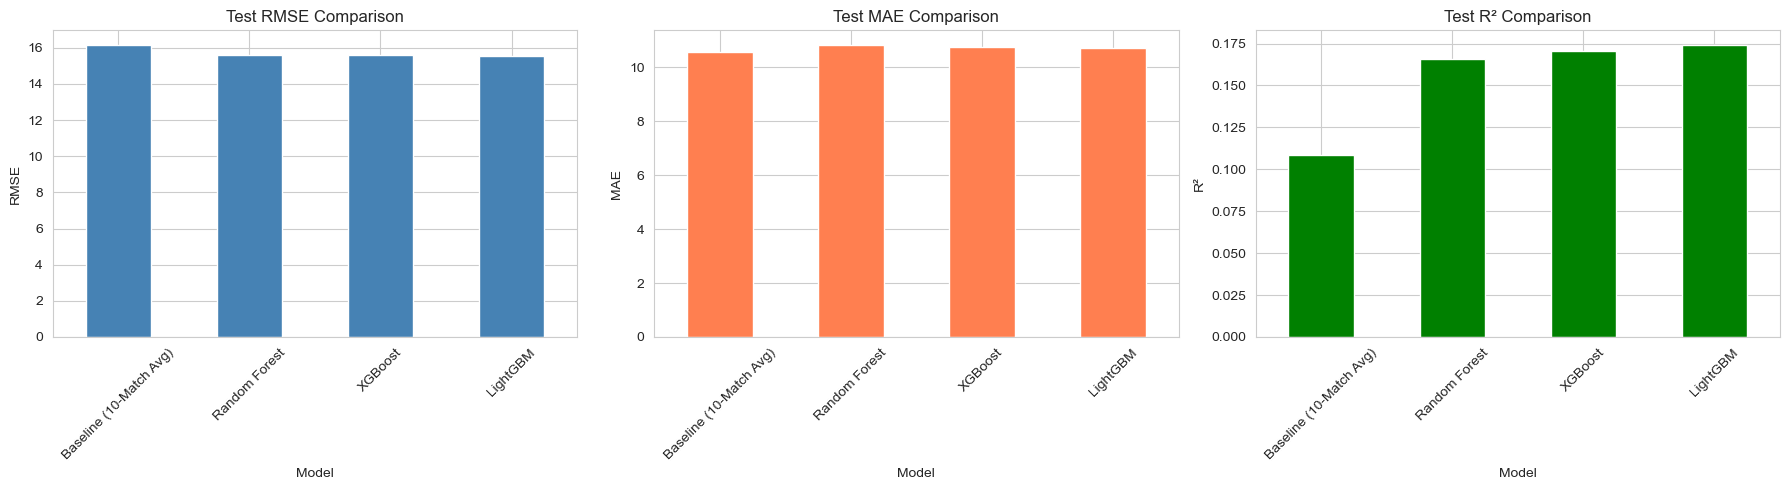

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

results_plot = results.set_index('Model')

results_plot[['Test_RMSE']].plot(kind='bar', ax=axes[0], color='steelblue', legend=False)
axes[0].set_title('Test RMSE Comparison')
axes[0].set_ylabel('RMSE')
axes[0].set_xlabel('Model')
axes[0].tick_params(axis='x', rotation=45)

results_plot[['Test_MAE']].plot(kind='bar', ax=axes[1], color='coral', legend=False)
axes[1].set_title('Test MAE Comparison')
axes[1].set_ylabel('MAE')
axes[1].set_xlabel('Model')
axes[1].tick_params(axis='x', rotation=45)

results_plot[['Test_R2']].plot(kind='bar', ax=axes[2], color='green', legend=False)
axes[2].set_title('Test R² Comparison')
axes[2].set_ylabel('R²')
axes[2].set_xlabel('Model')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Hyperparameter Tuning - XGBoost with Optuna

In [24]:
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 7),
        'gamma': trial.suggest_float('gamma', 0, 0.5),
        'random_state': 42,
        'n_jobs': -1
    }
    
    model = xgb.XGBRegressor(**params)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    return rmse

study_xgb = optuna.create_study(direction='minimize', study_name='xgb_optimization')
study_xgb.optimize(objective_xgb, n_trials=50, show_progress_bar=True)

print("\n" + "="*60)
print("XGBoost Hyperparameter Tuning Results")
print("="*60)
print(f"Best RMSE: {study_xgb.best_value:.4f}")
print(f"\nBest Parameters:")
for key, value in study_xgb.best_params.items():
    print(f"  {key}: {value}")
print("="*60)

[I 2026-01-08 18:39:25,722] A new study created in memory with name: xgb_optimization


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-01-08 18:39:27,280] Trial 0 finished with value: 16.75464771301868 and parameters: {'n_estimators': 409, 'max_depth': 6, 'learning_rate': 0.19389931340595323, 'subsample': 0.6428727622136355, 'colsample_bytree': 0.9173534001935105, 'min_child_weight': 2, 'gamma': 0.378252686253572}. Best is trial 0 with value: 16.75464771301868.
[I 2026-01-08 18:39:28,323] Trial 1 finished with value: 16.23638782345519 and parameters: {'n_estimators': 235, 'max_depth': 7, 'learning_rate': 0.13766646077319686, 'subsample': 0.6521471258958307, 'colsample_bytree': 0.8101353136909656, 'min_child_weight': 2, 'gamma': 0.21104773416325484}. Best is trial 1 with value: 16.23638782345519.
[I 2026-01-08 18:39:32,012] Trial 2 finished with value: 15.804782726525866 and parameters: {'n_estimators': 343, 'max_depth': 10, 'learning_rate': 0.032154855246669646, 'subsample': 0.7265513237225846, 'colsample_bytree': 0.723243190462147, 'min_child_weight': 1, 'gamma': 0.10457983946077903}. Best is trial 2 with val

## Train Best XGBoost Model

In [25]:
best_xgb_model = xgb.XGBRegressor(**study_xgb.best_params, random_state=42, n_jobs=-1)
best_xgb_model.fit(X_train, y_train)

y_pred_best_train = best_xgb_model.predict(X_train)
y_pred_best_test = best_xgb_model.predict(X_test)

best_rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_best_train))
best_mae_train = mean_absolute_error(y_train, y_pred_best_train)
best_r2_train = r2_score(y_train, y_pred_best_train)

best_rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_best_test))
best_mae_test = mean_absolute_error(y_test, y_pred_best_test)
best_r2_test = r2_score(y_test, y_pred_best_test)

print("="*60)
print("TUNED XGBOOST MODEL - FINAL RESULTS")
print("="*60)
print(f"\nTraining Set:")
print(f"  RMSE: {best_rmse_train:.4f}")
print(f"  MAE: {best_mae_train:.4f}")
print(f"  R2: {best_r2_train:.4f}")

print(f"\nTest Set:")
print(f"  RMSE: {best_rmse_test:.4f}")
print(f"  MAE: {best_mae_test:.4f}")
print(f"  R2: {best_r2_test:.4f}")

print(f"\nImprovement over baseline:")
print(f"  RMSE: {((baseline_rmse_test - best_rmse_test) / baseline_rmse_test * 100):.2f}%")
print(f"  MAE: {((baseline_mae_test - best_mae_test) / baseline_mae_test * 100):.2f}%")
print(f"  R2: {((best_r2_test - baseline_r2_test) / baseline_r2_test * 100):.2f}%")
print("="*60)

TUNED XGBOOST MODEL - FINAL RESULTS

Training Set:
  RMSE: 15.6890
  MAE: 10.7124
  R2: 0.2063

Test Set:
  RMSE: 15.4116
  MAE: 10.6026
  R2: 0.1884

Improvement over baseline:
  RMSE: 4.60%
  MAE: -0.42%
  R2: 74.02%


## Hyperparameter Tuning - LightGBM with GridSearchCV

In [26]:
lgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 7, 9],
    'learning_rate': [0.05, 0.1, 0.15],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

lgb_base = lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1)

lgb_grid_search = GridSearchCV(
    estimator=lgb_base,
    param_grid=lgb_param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=2
)

lgb_grid_search.fit(X_train, y_train)

print("\n" + "="*60)
print("LightGBM GridSearchCV Results")
print("="*60)
print(f"Best RMSE: {-lgb_grid_search.best_score_:.4f}")
print(f"\nBest Parameters:")
for key, value in lgb_grid_search.best_params_.items():
    print(f"  {key}: {value}")
print("="*60)

Fitting 3 folds for each of 243 candidates, totalling 729 fits

LightGBM GridSearchCV Results
Best RMSE: 15.8148

Best Parameters:
  colsample_bytree: 0.9
  learning_rate: 0.05
  max_depth: 5
  n_estimators: 100
  subsample: 0.7


## Train Best LightGBM Model

In [27]:
best_lgb_model = lgb_grid_search.best_estimator_

y_pred_lgb_best_train = best_lgb_model.predict(X_train)
y_pred_lgb_best_test = best_lgb_model.predict(X_test)

best_lgb_rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_lgb_best_train))
best_lgb_mae_train = mean_absolute_error(y_train, y_pred_lgb_best_train)
best_lgb_r2_train = r2_score(y_train, y_pred_lgb_best_train)

best_lgb_rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_lgb_best_test))
best_lgb_mae_test = mean_absolute_error(y_test, y_pred_lgb_best_test)
best_lgb_r2_test = r2_score(y_test, y_pred_lgb_best_test)

print("="*60)
print("TUNED LIGHTGBM MODEL - FINAL RESULTS")
print("="*60)
print(f"\nTraining Set:")
print(f"  RMSE: {best_lgb_rmse_train:.4f}")
print(f"  MAE: {best_lgb_mae_train:.4f}")
print(f"  R2: {best_lgb_r2_train:.4f}")

print(f"\nTest Set:")
print(f"  RMSE: {best_lgb_rmse_test:.4f}")
print(f"  MAE: {best_lgb_mae_test:.4f}")
print(f"  R2: {best_lgb_r2_test:.4f}")
print("="*60)

TUNED LIGHTGBM MODEL - FINAL RESULTS

Training Set:
  RMSE: 15.4009
  MAE: 10.5118
  R2: 0.2352

Test Set:
  RMSE: 15.4488
  MAE: 10.6349
  R2: 0.1845


## Final Model Comparison (After Tuning)

In [28]:
final_results = pd.DataFrame({
    'Model': ['Baseline', 'Random Forest', 'XGBoost', 'LightGBM', 'XGBoost (Tuned)', 'LightGBM (Tuned)'],
    'Test_RMSE': [baseline_rmse_test, rf_rmse_test, xgb_rmse_test, lgb_rmse_test, best_rmse_test, best_lgb_rmse_test],
    'Test_MAE': [baseline_mae_test, rf_mae_test, xgb_mae_test, lgb_mae_test, best_mae_test, best_lgb_mae_test],
    'Test_R2': [baseline_r2_test, rf_r2_test, xgb_r2_test, lgb_r2_test, best_r2_test, best_lgb_r2_test]
})

print("\n" + "="*80)
print("FINAL MODEL COMPARISON (AFTER HYPERPARAMETER TUNING)")
print("="*80)
print(final_results.to_string(index=False))
print("="*80)

best_model_idx = final_results['Test_RMSE'].idxmin()
best_model_name = final_results.loc[best_model_idx, 'Model']
print(f"\nBest Model: {best_model_name}")
print(f"  Test RMSE: {final_results.loc[best_model_idx, 'Test_RMSE']:.4f}")
print(f"  Test MAE: {final_results.loc[best_model_idx, 'Test_MAE']:.4f}")
print(f"  Test R2: {final_results.loc[best_model_idx, 'Test_R2']:.4f}")
print("="*80)


FINAL MODEL COMPARISON (AFTER HYPERPARAMETER TUNING)
           Model  Test_RMSE  Test_MAE  Test_R2
        Baseline  16.154648 10.557709 0.108271
   Random Forest  15.623617 10.831287 0.165932
         XGBoost  15.578867 10.745305 0.170704
        LightGBM  15.546496 10.720180 0.174146
 XGBoost (Tuned)  15.411582 10.602554 0.188418
LightGBM (Tuned)  15.448835 10.634863 0.184490

Best Model: XGBoost (Tuned)
  Test RMSE: 15.4116
  Test MAE: 10.6026
  Test R2: 0.1884


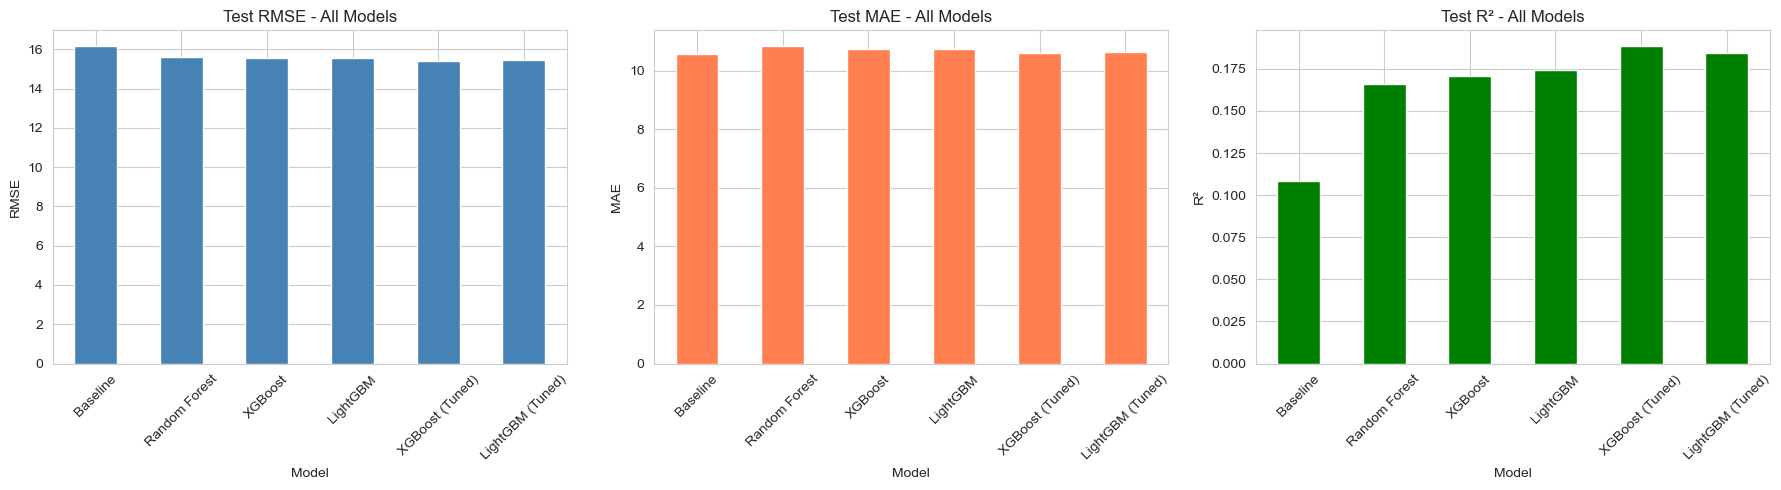

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

final_results_plot = final_results.set_index('Model')

final_results_plot[['Test_RMSE']].plot(kind='bar', ax=axes[0], color='steelblue', legend=False)
axes[0].set_title('Test RMSE - All Models')
axes[0].set_ylabel('RMSE')
axes[0].set_xlabel('Model')
axes[0].tick_params(axis='x', rotation=45)

final_results_plot[['Test_MAE']].plot(kind='bar', ax=axes[1], color='coral', legend=False)
axes[1].set_title('Test MAE - All Models')
axes[1].set_ylabel('MAE')
axes[1].set_xlabel('Model')
axes[1].tick_params(axis='x', rotation=45)

final_results_plot[['Test_R2']].plot(kind='bar', ax=axes[2], color='green', legend=False)
axes[2].set_title('Test R² - All Models')
axes[2].set_ylabel('R²')
axes[2].set_xlabel('Model')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Prediction Analysis - Actual vs Predicted

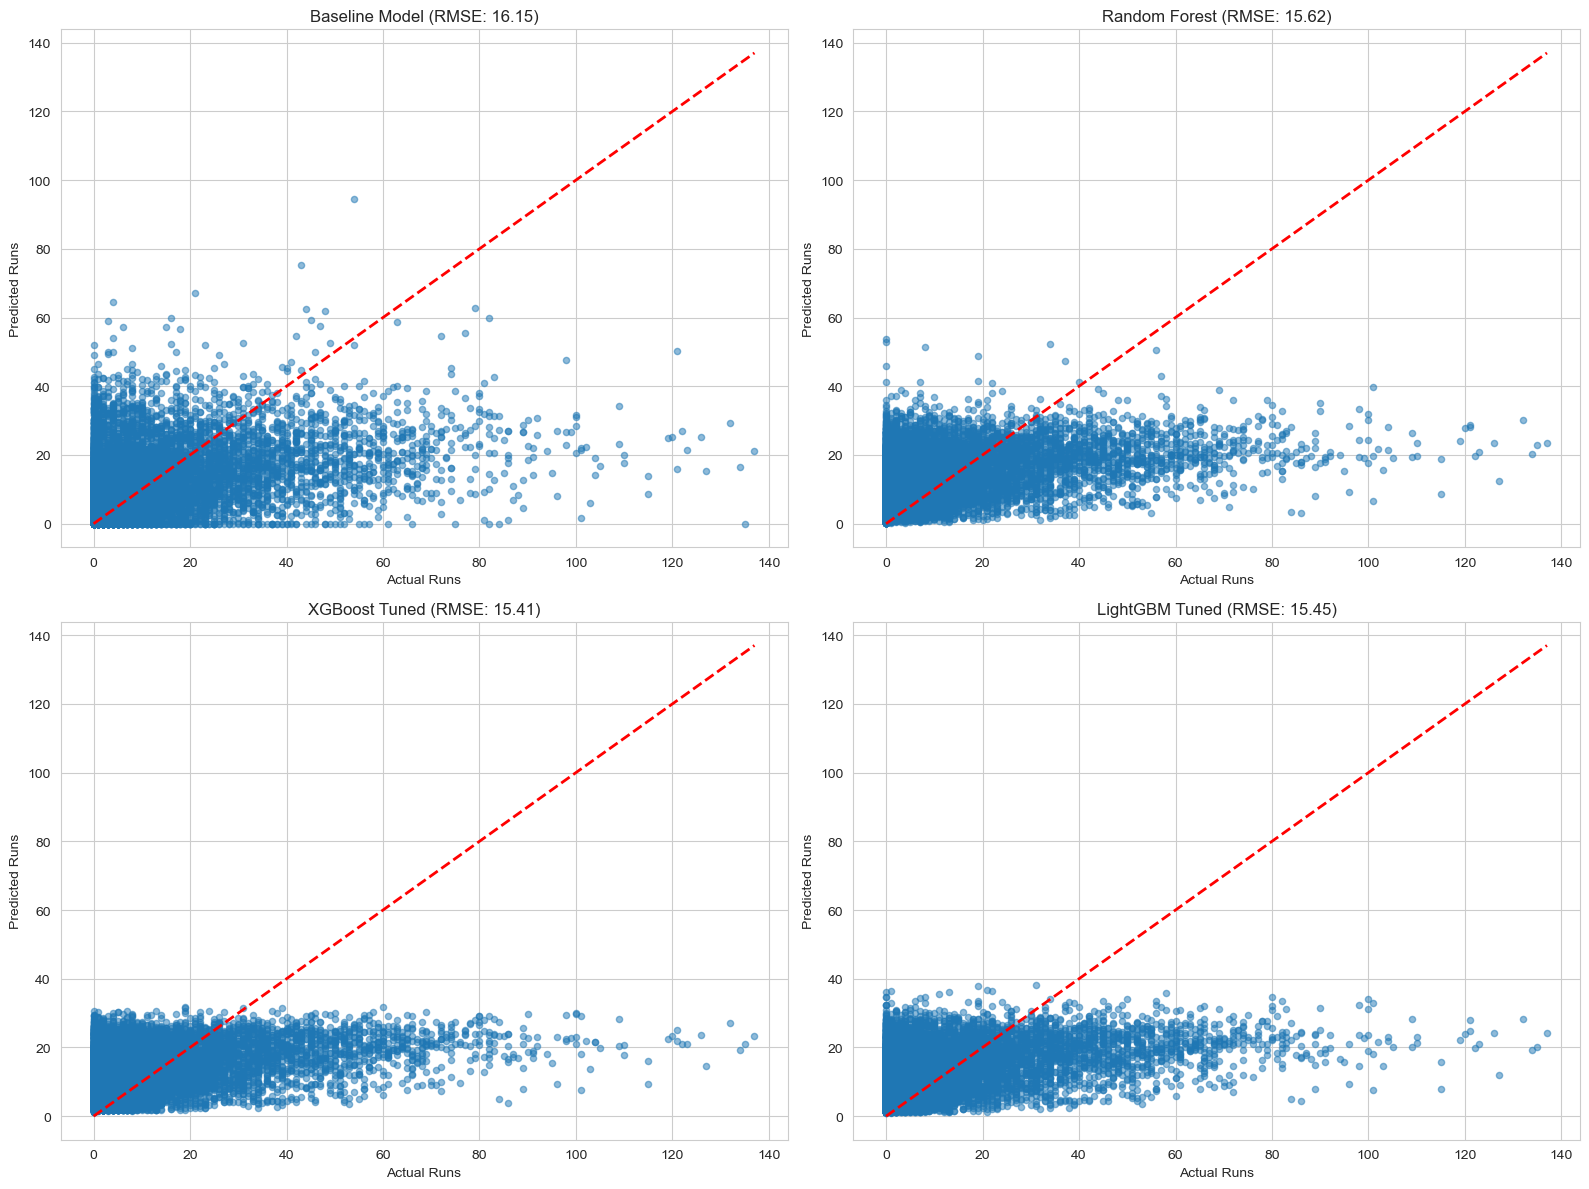

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].scatter(y_test, y_baseline_test, alpha=0.5, s=20)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual Runs')
axes[0, 0].set_ylabel('Predicted Runs')
axes[0, 0].set_title(f'Baseline Model (RMSE: {baseline_rmse_test:.2f})')

axes[0, 1].scatter(y_test, y_pred_rf_test, alpha=0.5, s=20)
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 1].set_xlabel('Actual Runs')
axes[0, 1].set_ylabel('Predicted Runs')
axes[0, 1].set_title(f'Random Forest (RMSE: {rf_rmse_test:.2f})')

axes[1, 0].scatter(y_test, y_pred_best_test, alpha=0.5, s=20)
axes[1, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1, 0].set_xlabel('Actual Runs')
axes[1, 0].set_ylabel('Predicted Runs')
axes[1, 0].set_title(f'XGBoost Tuned (RMSE: {best_rmse_test:.2f})')

axes[1, 1].scatter(y_test, y_pred_lgb_best_test, alpha=0.5, s=20)
axes[1, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1, 1].set_xlabel('Actual Runs')
axes[1, 1].set_ylabel('Predicted Runs')
axes[1, 1].set_title(f'LightGBM Tuned (RMSE: {best_lgb_rmse_test:.2f})')

plt.tight_layout()
plt.show()

## Residual Analysis

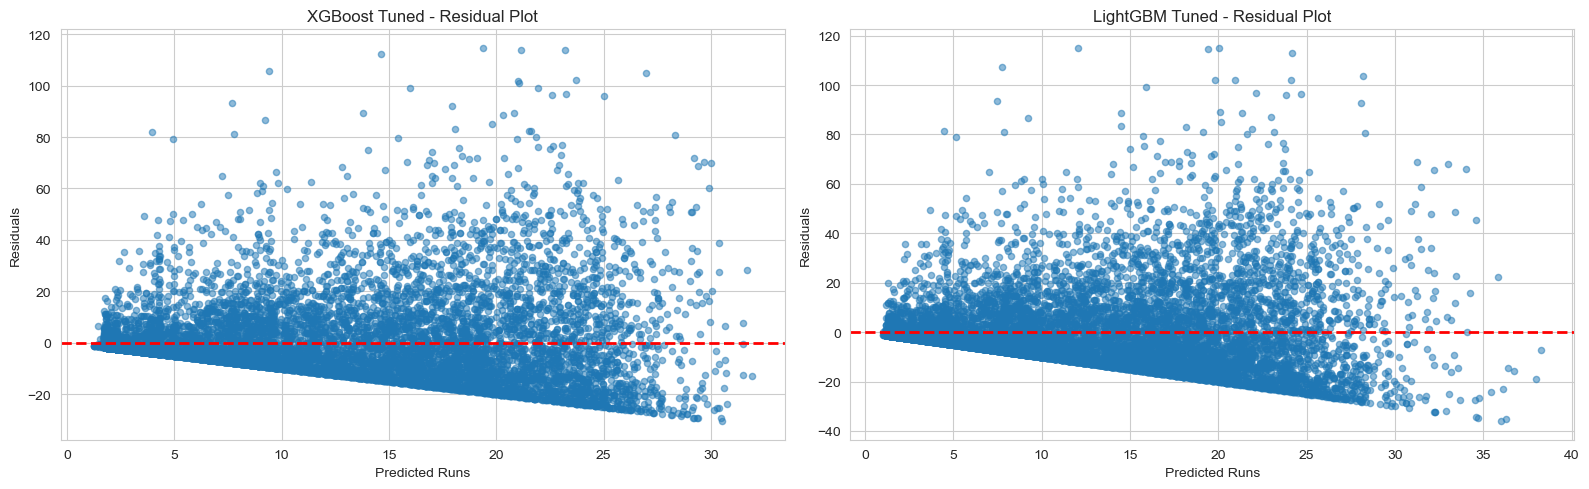

In [31]:
residuals_xgb = y_test - y_pred_best_test
residuals_lgb = y_test - y_pred_lgb_best_test

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].scatter(y_pred_best_test, residuals_xgb, alpha=0.5, s=20)
axes[0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0].set_xlabel('Predicted Runs')
axes[0].set_ylabel('Residuals')
axes[0].set_title('XGBoost Tuned - Residual Plot')

axes[1].scatter(y_pred_lgb_best_test, residuals_lgb, alpha=0.5, s=20)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Runs')
axes[1].set_ylabel('Residuals')
axes[1].set_title('LightGBM Tuned - Residual Plot')

plt.tight_layout()
plt.show()

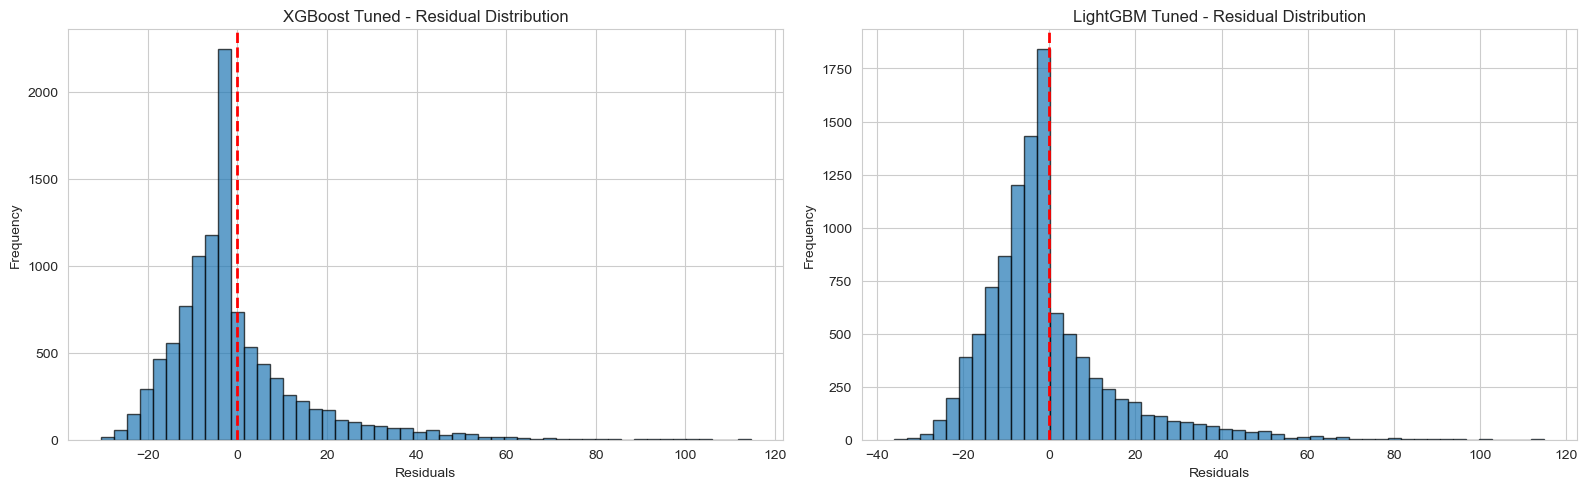

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(residuals_xgb, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Residuals')
axes[0].set_ylabel('Frequency')
axes[0].set_title('XGBoost Tuned - Residual Distribution')
axes[0].axvline(x=0, color='r', linestyle='--', lw=2)

axes[1].hist(residuals_lgb, bins=50, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Frequency')
axes[1].set_title('LightGBM Tuned - Residual Distribution')
axes[1].axvline(x=0, color='r', linestyle='--', lw=2)

plt.tight_layout()
plt.show()

## Feature Importance Analysis


Top 10 Most Important Features (XGBoost):
            Feature  Importance
       runs_last_10    0.333709
         career_avg    0.277639
     prev_venue_avg    0.087619
        runs_last_5    0.080517
        runs_last_3    0.049396
  prev_opponent_avg    0.046427
strike_rate_last_10    0.028207
     career_matches    0.026300
 strike_rate_last_5    0.015929
          career_sr    0.012177


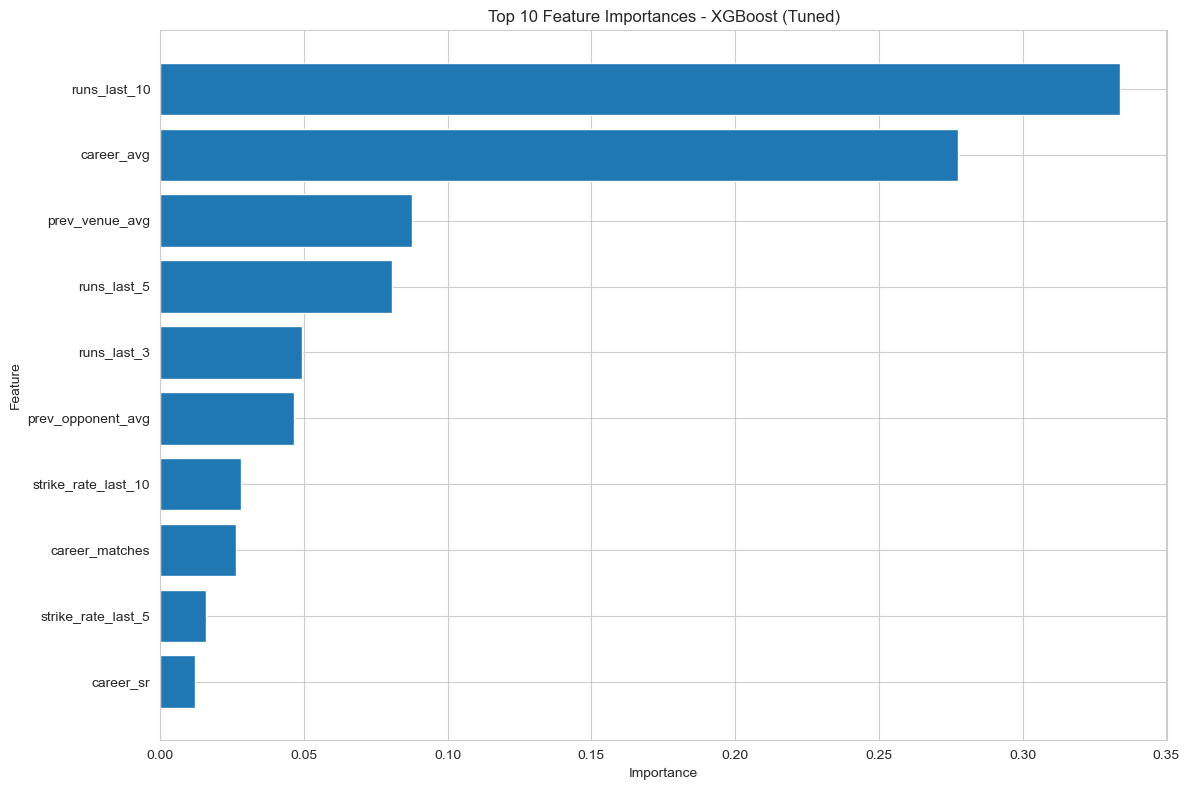

In [33]:
feature_importance_xgb = pd.DataFrame({
    'Feature': batting_features,
    'Importance': best_xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Most Important Features (XGBoost):")
print(feature_importance_xgb.head(10).to_string(index=False))

plt.figure(figsize=(12, 8))
plt.barh(range(10), feature_importance_xgb.head(10)['Importance'])
plt.yticks(range(10), feature_importance_xgb.head(10)['Feature'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 Feature Importances - XGBoost (Tuned)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## SHAP Analysis - Feature Importance

In [34]:
explainer = shap.TreeExplainer(best_xgb_model)
shap_values = explainer.shap_values(X_test)

print("SHAP values computed successfully")
print(f"SHAP values shape: {shap_values.shape}")

SHAP values computed successfully
SHAP values shape: (10496, 14)


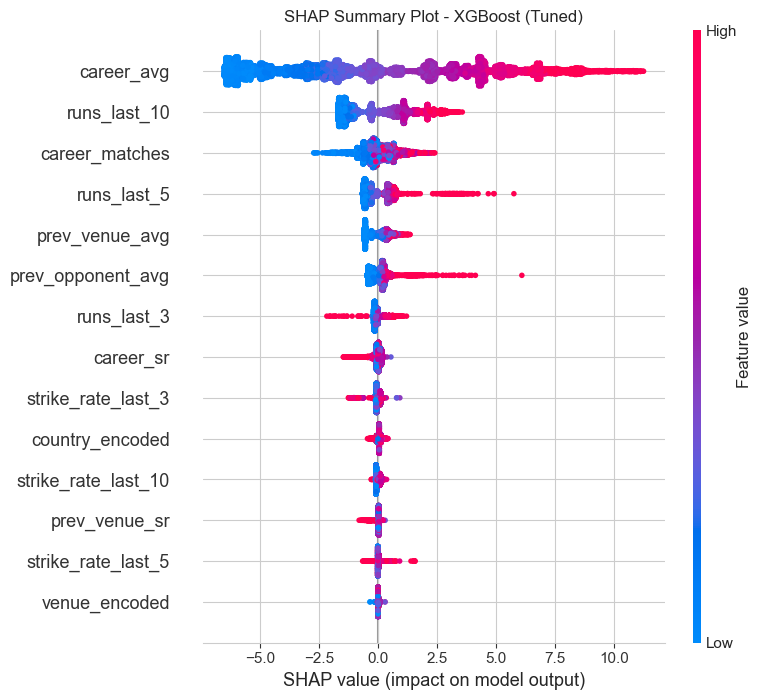

In [35]:
shap.summary_plot(shap_values, X_test, feature_names=batting_features, show=False)
plt.title('SHAP Summary Plot - XGBoost (Tuned)')
plt.tight_layout()
plt.show()

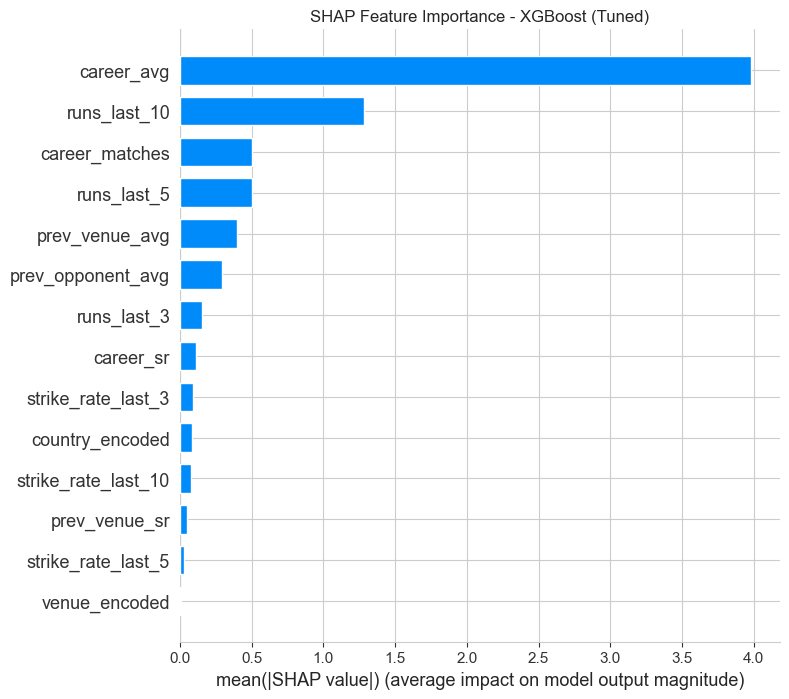

In [36]:
shap.summary_plot(shap_values, X_test, feature_names=batting_features, plot_type="bar", show=False)
plt.title('SHAP Feature Importance - XGBoost (Tuned)')
plt.tight_layout()
plt.show()

In [37]:
shap_importance = pd.DataFrame({
    'Feature': batting_features,
    'SHAP_Importance': np.abs(shap_values).mean(axis=0)
}).sort_values('SHAP_Importance', ascending=False)

print("\nTop 10 Features by SHAP Importance:")
print(shap_importance.head(10).to_string(index=False))


Top 10 Features by SHAP Importance:
           Feature  SHAP_Importance
        career_avg         3.983040
      runs_last_10         1.286599
    career_matches         0.505752
       runs_last_5         0.503961
    prev_venue_avg         0.395597
 prev_opponent_avg         0.291597
       runs_last_3         0.156133
         career_sr         0.113854
strike_rate_last_3         0.088259
   country_encoded         0.088134


## SHAP Dependence Plots

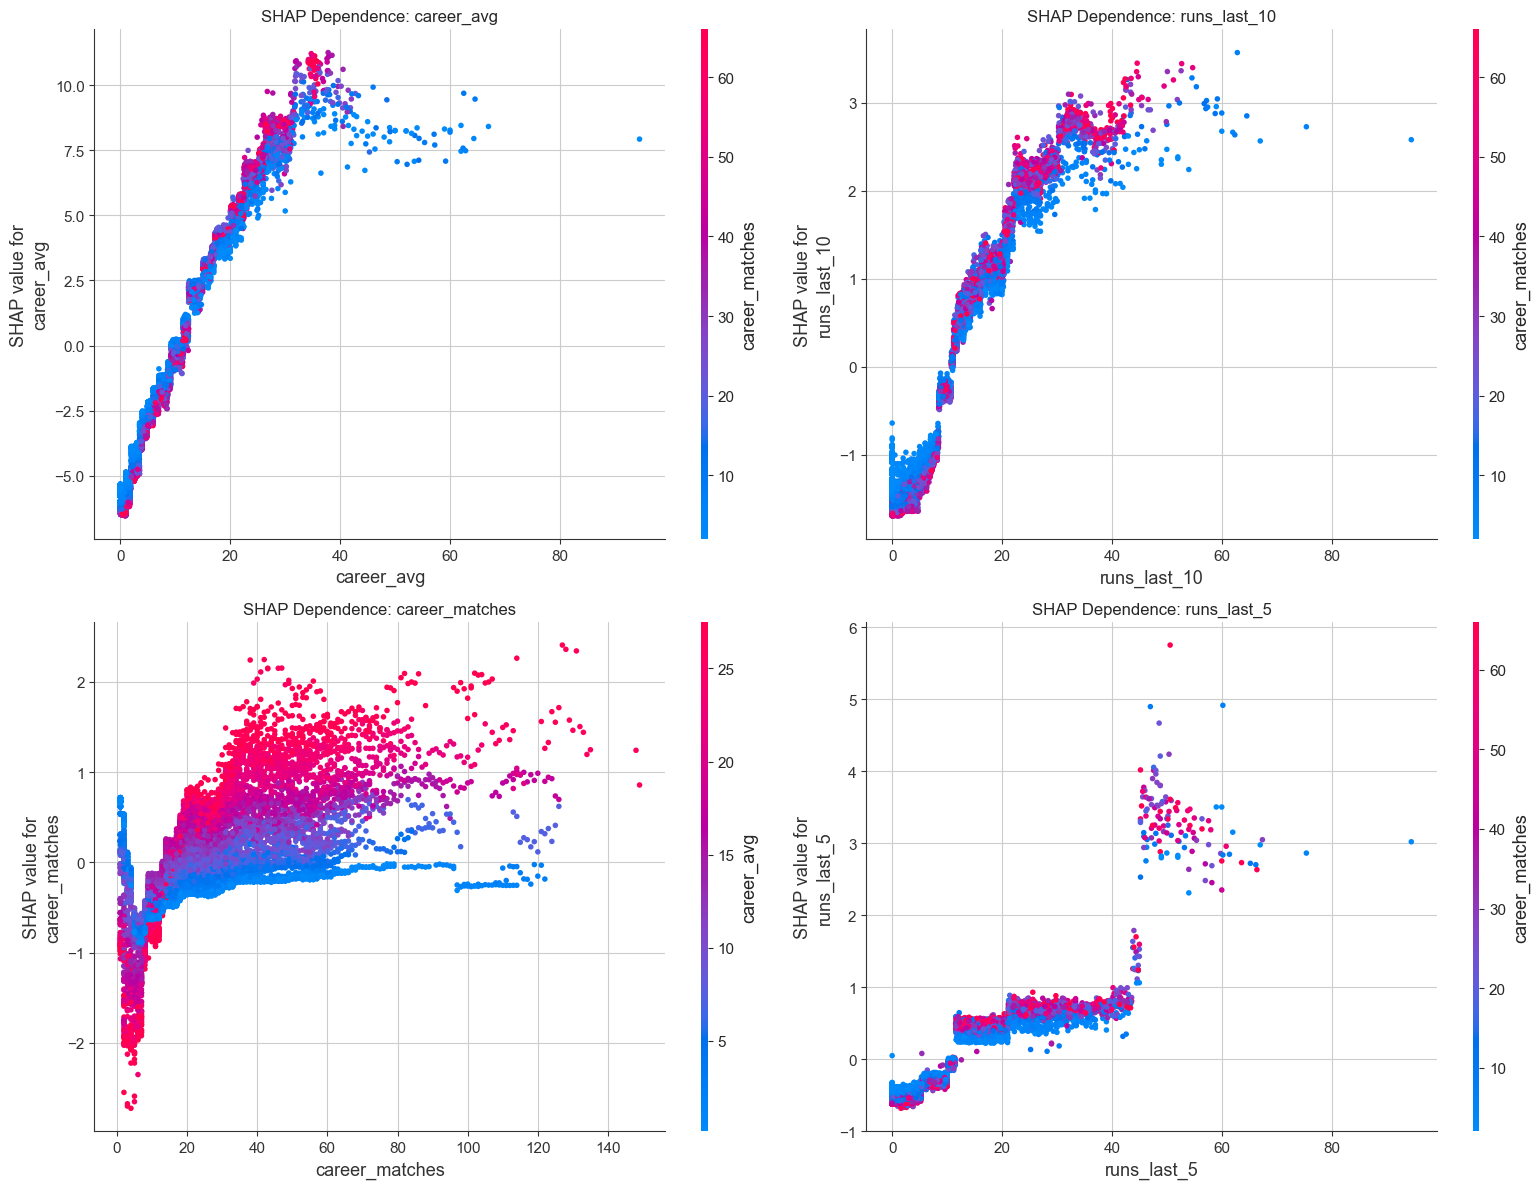

In [38]:
top_features = shap_importance.head(4)['Feature'].tolist()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for idx, feature in enumerate(top_features):
    feature_idx = batting_features.index(feature)
    shap.dependence_plot(
        feature_idx,
        shap_values,
        X_test,
        feature_names=batting_features,
        ax=axes[idx],
        show=False
    )
    axes[idx].set_title(f'SHAP Dependence: {feature}')

plt.tight_layout()
plt.show()

## Save Model Artifacts

In [39]:
import os

project_root = r'd:\Projects\AIagent\Cricket Score Prediction System'
models_dir = os.path.join(project_root, 'models')

if not os.path.exists(models_dir):
    os.makedirs(models_dir)

xgb_model_path = os.path.join(models_dir, 'xgb_model.joblib')
lgb_model_path = os.path.join(models_dir, 'lgb_model.joblib')
rf_model_path = os.path.join(models_dir, 'rf_model.joblib')
results_path = os.path.join(models_dir, 'model_results.csv')
shap_values_path = os.path.join(models_dir, 'shap_values.npy')

joblib.dump(best_xgb_model, xgb_model_path)
joblib.dump(best_lgb_model, lgb_model_path)
joblib.dump(rf_model, rf_model_path)
final_results.to_csv(results_path, index=False)
np.save(shap_values_path, shap_values)

print("="*60)
print("MODEL ARTIFACTS SAVED")
print("="*60)
print(f"XGBoost Model: {xgb_model_path}")
print(f"LightGBM Model: {lgb_model_path}")
print(f"Random Forest Model: {rf_model_path}")
print(f"Results CSV: {results_path}")
print(f"SHAP Values: {shap_values_path}")
print("="*60)

MODEL ARTIFACTS SAVED
XGBoost Model: d:\Projects\AIagent\Cricket Score Prediction System\models\xgb_model.joblib
LightGBM Model: d:\Projects\AIagent\Cricket Score Prediction System\models\lgb_model.joblib
Random Forest Model: d:\Projects\AIagent\Cricket Score Prediction System\models\rf_model.joblib
Results CSV: d:\Projects\AIagent\Cricket Score Prediction System\models\model_results.csv
SHAP Values: d:\Projects\AIagent\Cricket Score Prediction System\models\shap_values.npy


## Training Summary

In [40]:
print("\n" + "="*80)
print("MODEL TRAINING SUMMARY")
print("="*80)

print(f"\nDataset Information:")
print(f"  Total Records: {len(batting_dataset)}")
print(f"  Training Records: {len(batting_train)} ({len(batting_train)/len(batting_dataset)*100:.1f}%)")
print(f"  Test Records: {len(batting_test)} ({len(batting_test)/len(batting_dataset)*100:.1f}%)")
print(f"  Number of Features: {len(batting_features)}")

print(f"\nModels Trained:")
print(f"  1. Baseline (10-Match Rolling Average)")
print(f"  2. Random Forest")
print(f"  3. XGBoost")
print(f"  4. LightGBM")
print(f"  5. XGBoost (Optuna Tuned) - {study_xgb.best_trial.number + 1} trials")
print(f"  6. LightGBM (GridSearchCV Tuned) - {len(lgb_grid_search.cv_results_['params'])} combinations")

print(f"\nBest Performing Model:")
print(f"  Model: {best_model_name}")
print(f"  Test RMSE: {final_results.loc[best_model_idx, 'Test_RMSE']:.4f}")
print(f"  Test MAE: {final_results.loc[best_model_idx, 'Test_MAE']:.4f}")
print(f"  Test R²: {final_results.loc[best_model_idx, 'Test_R2']:.4f}")

print(f"\nFeature Analysis:")
print(f"  Top 3 Important Features (SHAP):")
for idx, row in shap_importance.head(3).iterrows():
    print(f"    {idx+1}. {row['Feature']}: {row['SHAP_Importance']:.4f}")

print(f"\nArtifacts Saved:")
print(f"  ✓ xgb_model.joblib")
print(f"  ✓ lgb_model.joblib")
print(f"  ✓ rf_model.joblib")
print(f"  ✓ model_results.csv")
print(f"  ✓ shap_values.npy")

print("\n" + "="*80)
print("TRAINING COMPLETE")
print("="*80)


MODEL TRAINING SUMMARY

Dataset Information:
  Total Records: 52495
  Training Records: 41949 (79.9%)
  Test Records: 10496 (20.0%)
  Number of Features: 14

Models Trained:
  1. Baseline (10-Match Rolling Average)
  2. Random Forest
  3. XGBoost
  4. LightGBM
  5. XGBoost (Optuna Tuned) - 43 trials
  6. LightGBM (GridSearchCV Tuned) - 243 combinations

Best Performing Model:
  Model: XGBoost (Tuned)
  Test RMSE: 15.4116
  Test MAE: 10.6026
  Test R²: 0.1884

Feature Analysis:
  Top 3 Important Features (SHAP):
    2. career_avg: 3.9830
    6. runs_last_10: 1.2866
    1. career_matches: 0.5058

Artifacts Saved:
  ✓ xgb_model.joblib
  ✓ lgb_model.joblib
  ✓ rf_model.joblib
  ✓ model_results.csv
  ✓ shap_values.npy

TRAINING COMPLETE
